<a href="https://colab.research.google.com/github/rishi-masurkar01/AI-Projects-Portfolio/blob/main/Sentiment_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Imports & Library Setup ────────────────────────────────────────────────────
# Install all required libraries for the project
!pip install nltk scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import re                    # Regular expressions for text cleaning
import nltk                  # Natural Language Toolkit
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
# ── Dataset Loading ────────────────────────────────────────────────────────────
# Load the IMDB dataset (50,000 movie reviews) directly from HuggingFace.
# No manual download needed — datasets library handles it automatically.

!pip install datasets -q
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")
df = pd.DataFrame({
    "review":    dataset["train"]["text"],
    "sentiment": dataset["train"]["label"]
})
df["sentiment"] = df["sentiment"].map({1: "positive", 0: "negative"})

print(f"✅ Dataset loaded: {df.shape[0]} rows")
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Dataset loaded: 25000 rows


,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative
3,This film was probably inspired by Godard's Ma...,negative
4,"Oh, brother...after hearing about this ridicul...",negative


Shape: (25000, 2)
Sentiment distribution:
sentiment
negative    12500
positive    12500
Name: count, dtype: int64


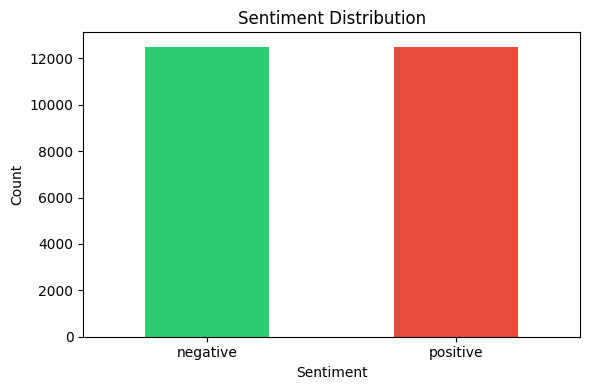

In [3]:
# ── Exploratory Data Analysis ──────────────────────────────────────────────────
# Understand the dataset structure and check for class imbalance.
# A balanced dataset (equal positive/negative) gives more reliable model metrics.

print("Shape:", df.shape)
print("Sentiment distribution:")
print(df["sentiment"].value_counts())

plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# ── Text Preprocessing ─────────────────────────────────────────────────────────
# Clean raw review text before feature extraction.
# Each step removes noise that would confuse the model.

stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """
    Clean a raw movie review for NLP processing.

    Steps applied in order:
      1. Lowercase          — normalizes case ("Great" == "great")
      2. Remove HTML tags   — IMDB reviews contain <br> tags
      3. Remove punctuation — keeps only letters and spaces
      4. Strip extra spaces — collapses multiple spaces to one
      5. Remove stopwords   — drops common words ("the", "is", "a")

    Args:
        text (str): Raw review string.

    Returns:
        str: Cleaned review ready for TF-IDF vectorization.
    """
    text = str(text).lower()                           # Step 1: Lowercase
    text = re.sub(r"<.*?>", "", text)                  # Step 2: Remove HTML
    text = re.sub(r"[^a-z\s]", "", text)              # Step 3: Remove punctuation
    text = re.sub(r"\s+", " ", text).strip()           # Step 4: Strip whitespace
    words = [w for w in text.split() if w not in stop_words]  # Step 5: Stopwords
    return " ".join(words)

print("🔄 Cleaning text... (takes ~30 seconds)")
df["clean_review"] = df["review"].apply(clean_text)
print("✅ Text cleaned!")

# Show before/after to verify cleaning is working correctly
print("--- BEFORE ---")
print(df["review"].iloc[0][:300])
print("--- AFTER ---")
print(df["clean_review"].iloc[0][:300])

🔄 Cleaning text... (takes ~30 seconds)
✅ Text cleaned!
--- BEFORE ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
--- AFTER ---
rented curiousyellow video store controversy surrounded first released also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular want


In [5]:
# ── Train/Test Split ───────────────────────────────────────────────────────────
# Split into 80% training, 20% testing.
# stratify=y ensures equal positive/negative ratio in both splits.

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% held out for evaluation
    random_state=42,  # Fixed seed for reproducibility
    stratify=y        # Maintain class balance in both splits
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 20000
Test size:  5000


In [6]:
# ── TF-IDF Feature Extraction ──────────────────────────────────────────────────
# TF-IDF (Term Frequency–Inverse Document Frequency) converts text into
# numerical vectors the model can process.
#   max_features=10000  — use only the 10,000 most important words
#   ngram_range=(1,2)   — capture single words AND 2-word phrases (e.g. "not good")

import pickle

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)  # Learn vocab + transform
X_test_tfidf  = tfidf.transform(X_test)       # Transform only (no fitting)

print(f"✅ TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"   Each review is now a vector of {X_train_tfidf.shape[1]} features")

# Save all data to disk so Day 2 can load it without rerunning Day 1
with open("tfidf_data.pkl", "wb") as f:
    pickle.dump((X_train_tfidf, X_test_tfidf, y_train, y_test, tfidf), f)

print("💾 Data saved! Ready for Day 2.")

✅ TF-IDF matrix shape: (20000, 10000)
   Each review is now a vector of 10000 features
💾 Data saved! Ready for Day 2.


In [7]:
# ── Day 2: Load Saved Data ─────────────────────────────────────────────────────
# Load the TF-IDF matrices and labels saved at the end of Day 1.
# If this cell throws FileNotFoundError, re-run Day 1 cells first.

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

with open("tfidf_data.pkl", "rb") as f:
    X_train_tfidf, X_test_tfidf, y_train, y_test, tfidf = pickle.load(f)

print("✅ Day 1 data loaded successfully!")
print(f"   Training samples: {X_train_tfidf.shape[0]}")
print(f"   Test samples:     {X_test_tfidf.shape[0]}")

✅ Day 1 data loaded successfully!
   Training samples: 20000
   Test samples:     5000


In [8]:
# ── Model 1: Logistic Regression ───────────────────────────────────────────────
# Logistic Regression works well for text because TF-IDF features are
# high-dimensional and sparse — exactly the kind LR handles efficiently.
# C=1.0 controls regularization strength (higher = less regularization).

from sklearn.linear_model import LogisticRegression
import time

print("🔄 Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

elapsed  = time.time() - start
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"✅ Done in {elapsed:.1f}s")
print(f"📊 Accuracy: {lr_acc * 100:.2f}%")
print()
print(classification_report(y_test, lr_preds, target_names=["Negative", "Positive"]))

🔄 Training Logistic Regression...
✅ Done in 0.2s
📊 Accuracy: 89.22%

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      2500
    Positive       0.88      0.91      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [9]:
# ── Model 2: Support Vector Machine ────────────────────────────────────────────
# LinearSVC is an SVM variant optimized for large, sparse datasets like TF-IDF.
# Generally slightly more accurate than LR on text but lacks probability output.

from sklearn.svm import LinearSVC

print("🔄 Training SVM...")
start = time.time()

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

elapsed   = time.time() - start
svm_preds = svm_model.predict(X_test_tfidf)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"✅ Done in {elapsed:.1f}s")
print(f"📊 Accuracy: {svm_acc * 100:.2f}%")
print()
print(classification_report(y_test, svm_preds, target_names=["Negative", "Positive"]))

🔄 Training SVM...
✅ Done in 0.8s
📊 Accuracy: 88.62%

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89      2500
    Positive       0.88      0.89      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



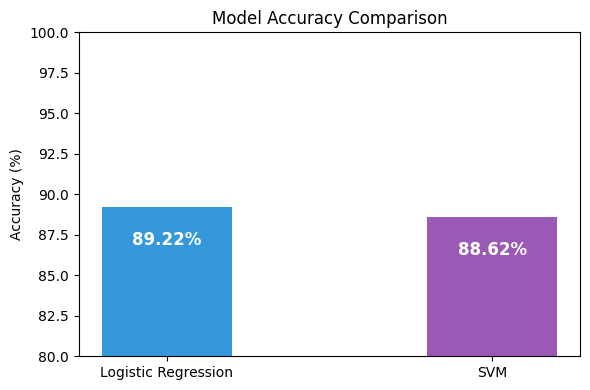

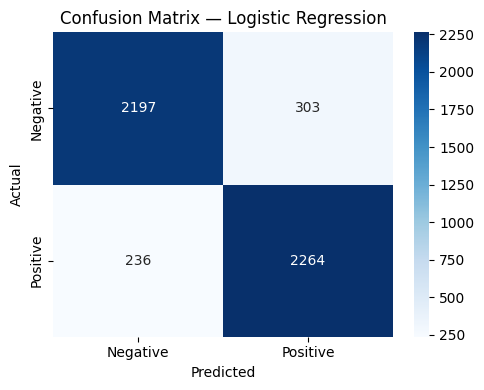

🏆 Best model: Logistic Regression with 89.22% accuracy


In [10]:
# ── Model Comparison ───────────────────────────────────────────────────────────
# Visualize both model accuracies side-by-side and inspect the confusion matrix
# of the best model to understand where it makes mistakes.

# Bar chart
models     = ["Logistic Regression", "SVM"]
accuracies = [lr_acc * 100, svm_acc * 100]
colors     = ["#3498db", "#9b59b6"]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=colors, width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 1.5,
             f"{acc:.2f}%", ha="center", va="top",
             color="white", fontweight="bold", fontsize=12)
plt.ylim(80, 100)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

# Confusion matrix for the winning model
best_preds = lr_preds if lr_acc >= svm_acc else svm_preds
best_name  = "Logistic Regression" if lr_acc >= svm_acc else "SVM"

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print(f"🏆 Best model: {best_name} with {max(lr_acc, svm_acc)*100:.2f}% accuracy")

In [11]:
# ── Save Best Model ─────────────────────────────────────────────────────────────
# Pickle saves both the trained model and the TF-IDF vectorizer together.
# Both are needed at inference time: vectorizer transforms input, model predicts.

best_model = lr_model if lr_acc >= svm_acc else svm_model
best_name  = "Logistic Regression" if lr_acc >= svm_acc else "SVM"

with open("best_model.pkl", "wb") as f:
    pickle.dump((best_model, tfidf), f)

print(f"💾 Saved: {best_name}")
print("✅ Ready for Day 3!")

💾 Saved: Logistic Regression
✅ Ready for Day 3!


In [12]:
# ── Day 3: GPU Check ────────────────────────────────────────────────────────────
# BERT requires a GPU to run in reasonable time.
# Go to: Runtime > Change Runtime Type > Hardware Accelerator > T4 GPU

!pip install transformers torch datasets -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ No GPU — go to Runtime > Change Runtime Type!")

GPU available: True
Device: Tesla T4


In [13]:
# ── Load Pre-trained DistilBERT ─────────────────────────────────────────────────
# DistilBERT is a smaller, faster version of BERT (40% fewer parameters,
# 60% faster) while retaining 97% of BERT performance.
# This model is already fine-tuned on SST-2 (sentiment dataset) — no training needed.

from transformers import pipeline

print("🔄 Loading pre-trained DistilBERT... (~1 minute)")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)
print("✅ Model loaded!")

# Quick sanity check on 3 test sentences
test_sentences = [
    "This movie was absolutely amazing!",
    "I wasted 2 hours of my life watching this.",
    "The acting was decent but the plot was boring."
]

results = sentiment_pipeline(test_sentences)
print("--- Quick Test ---")
for text, result in zip(test_sentences, results):
    emoji = "😊" if result["label"] == "POSITIVE" else "😞"
print(f"{emoji} {result['label']} ({result['score']*100:.1f}%) — '{text}'")

🔄 Loading pre-trained DistilBERT... (~1 minute)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Model loaded!
--- Quick Test ---
😞 NEGATIVE (99.9%) — 'The acting was decent but the plot was boring.'


In [14]:
# ── BERT Evaluation ─────────────────────────────────────────────────────────────
# Evaluate DistilBERT on 500 held-out test reviews.
# (Full 25k evaluation would take ~15 mins; 500 gives a reliable estimate)

from datasets import load_dataset
from sklearn.metrics import accuracy_score

print("🔄 Loading test data...")
dataset     = load_dataset("imdb")
test_texts  = dataset["test"]["text"][:500]
test_labels = dataset["test"]["label"][:500]

print("🔄 Running BERT on 500 reviews... (~2 minutes)")
bert_results = sentiment_pipeline(
    test_texts,
    batch_size=32,     # Process 32 reviews at a time for GPU efficiency
    truncation=True,   # Truncate reviews longer than 512 tokens
    max_length=512
)

bert_preds = [1 if r["label"] == "POSITIVE" else 0 for r in bert_results]
bert_acc   = accuracy_score(test_labels, bert_preds)

print(f"✅ BERT Accuracy: {bert_acc * 100:.2f}%")
print(f"   Your Day 2 score was: 89.22%")
print(f"   Improvement: +{(bert_acc - 0.8922) * 100:.2f}%")

🔄 Loading test data...
🔄 Running BERT on 500 reviews... (~2 minutes)
✅ BERT Accuracy: 90.60%
   Your Day 2 score was: 89.22%
   Improvement: +1.38%


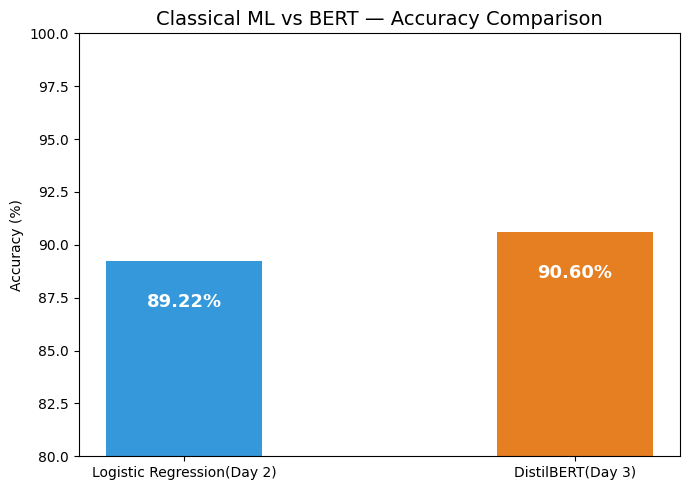

🏆 Classical ML:  89.22%
🤖 DistilBERT:    90.60%
💾 Saved! Ready for Day 4 UI!


In [15]:
# ── Final Accuracy Comparison Chart ─────────────────────────────────────────────
# Compare classical ML (TF-IDF + LR) vs transformer (DistilBERT).
# This chart is the key visual for your presentation.

import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import accuracy_score

with open("tfidf_data.pkl", "rb") as f:
    X_train_tfidf, X_test_tfidf, y_train, y_test, tfidf = pickle.load(f)

with open("best_model.pkl", "rb") as f:
    best_model, _ = pickle.load(f)

classical_acc = accuracy_score(y_test, best_model.predict(X_test_tfidf))

models = ["Logistic Regression(Day 2)", "DistilBERT(Day 3)"]
accs   = [classical_acc * 100, bert_acc * 100]
colors = ["#3498db", "#e67e22"]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accs, color=colors, width=0.4)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 1.5,
             f"{acc:.2f}%", ha="center", va="top",
             color="white", fontsize=13, fontweight="bold")
plt.ylim(80, 100)
plt.title("Classical ML vs BERT — Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

print(f"🏆 Classical ML:  {classical_acc*100:.2f}%")
print(f"🤖 DistilBERT:    {bert_acc*100:.2f}%")

# Persist bert_acc for the UI cells below
with open("bert_acc.pkl", "wb") as f:
    pickle.dump(bert_acc, f)
print("💾 Saved! Ready for Day 4 UI!")

In [16]:
# ── Day 4: Install UI Dependencies ──────────────────────────────────────────────
# Gradio is a Python library that creates interactive web UIs in one cell.
# It generates a public shareable link that works on any device.

!pip install gradio transformers torch -q

import gradio as gr
import pickle
import re
import nltk
import torch
from datetime import datetime
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from transformers import pipeline

print("✅ Gradio loaded!")
print("Gradio version:", gr.__version__)

✅ Gradio loaded!
Gradio version: 5.50.0


In [17]:
# ── Load Models & Define Helper Functions ───────────────────────────────────────
# Load both trained models and define all prediction + UI builder functions.
# Keeping functions separate improves readability and makes testing easier.

# ── Load saved models ──────────────────────────────
with open("best_model.pkl", "rb") as f:
    best_model, tfidf = pickle.load(f)

print("🔄 Loading DistilBERT... (~1 minute)")
bert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

stop_words = set(stopwords.words("english"))

# ── Config ──────────────────────────────────────────
MAX_HISTORY     = 10    # Max rows kept in the history table
BERT_MAX_TOKENS = 512   # DistilBERT max input length
CONFIDENCE_WARN = 60.0  # Show warning below this confidence %

# ── In-memory session history ───────────────────────
history_store = []

# ── Functions ───────────────────────────────────────

def clean_text(text: str) -> str:
    """
    Prepare raw review text for classical ML inference.
    Applies the same cleaning pipeline used during training.

    Args:
        text: Raw review string from the user.
    Returns:
        Cleaned string with HTML, punctuation and stopwords removed.
    """
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return " ".join([w for w in text.split() if w not in stop_words])


def predict_single(text: str, model_choice: str) -> dict:
    """
    Run sentiment prediction on a single review string.

    Args:
        text:         Raw input text from the user.
        model_choice: Either the LR or BERT option string.
    Returns:
        Dict with keys: label (str), confidence (float), model (str).
        On error, also includes an "error" key with the message.
    """
    try:
        if model_choice == "⚡ Logistic Regression (Fast)":
            vec        = tfidf.transform([clean_text(text)])
            pred       = best_model.predict(vec)[0]
            confidence = round(max(best_model.predict_proba(vec)[0]) * 100, 1)
            label      = "POSITIVE" if pred == 1 else "NEGATIVE"
        else:
            result     = bert_model(text, truncation=True, max_length=BERT_MAX_TOKENS)[0]
            label      = result["label"]
            confidence = round(result["score"] * 100, 1)
        return {"label": label, "confidence": confidence, "model": model_choice}
    except Exception as e:
        return {"label": "ERROR", "confidence": 0.0, "model": model_choice, "error": str(e)}


def build_result_html(label: str, confidence: float, word_count: int) -> str:
    """
    Build the colored result card HTML shown after prediction.
    Positive = sage green card, Negative = warm brown card.

    Args:
        label:      "POSITIVE", "NEGATIVE", or "ERROR".
        confidence: Model confidence as a percentage (0–100).
        word_count: Number of words in the original input.
    Returns:
        HTML string for the Gradio gr.HTML component.
    """
    if label == "POSITIVE":
        bg, radius, text = "linear-gradient(160deg, #BABF94 0%, #a8ad82 100%)", "4px 22px 4px 22px", "Positive ↑"
    elif label == "NEGATIVE":
        bg, radius, text = "linear-gradient(160deg, #A98B76 0%, #8f7260 100%)", "22px 4px 22px 4px", "Negative ↓"
    else:
        bg, radius, text = "linear-gradient(160deg, #888 0%, #555 100%)", "12px", "Error"

    warn = f"""<div style='margin-top:8px; background:rgba(255,255,255,0.2); border-radius:8px; padding:6px 10px; font-size:11px; color:#fff;'>⚠️ Low confidence — model is uncertain</div>""" if confidence < CONFIDENCE_WARN else ""

    return f"""
    <div style='background:{bg}; border-radius:{radius}; padding:24px 22px; position:relative; overflow:hidden;'>
        <div style='position:absolute; top:-18px; right:-6px; font-size:100px; opacity:0.1; line-height:1;'>✦</div>
        <div style='font-size:10px; letter-spacing:4px; text-transform:uppercase; color:rgba(255,255,255,0.75); font-weight:600; margin-bottom:6px;'>Sentiment Result</div>
        <div style='font-size:30px; font-weight:900; color:#fff; letter-spacing:-0.5px; line-height:1;'>{text}</div>
        <div style='margin-top:14px; height:3px; background:rgba(255,255,255,0.25); border-radius:99px; overflow:hidden;'>
            <div style='width:{confidence}%; height:100%; background:rgba(255,255,255,0.85); border-radius:99px;'></div>
        </div>
        <div style='color:rgba(255,255,255,0.85); font-size:12px; margin-top:8px;'>{confidence}% confidence · {word_count} words analyzed</div>
        {warn}
    </div>"""


def build_stats_html(model_choice: str, word_count: int) -> str:
    """
    Build the 3-column stats bar (model name, accuracy, word count).

    Args:
        model_choice: The selected model string.
        word_count:   Number of words in the input review.
    Returns:
        HTML string for the stats bar component.
    """
    acc = "89.22%" if "Logistic" in model_choice else "90.60%"
    mdl = "LR"     if "Logistic" in model_choice else "BERT"

    def stat(label, val):
        return f"<div style='flex:1; background:#fff; border:1px solid #BFA28C; border-radius:10px; padding:10px 12px;'><div style='font-size:9px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>{label}</div><div style='font-size:13px; font-weight:700; color:#3a3028; margin-top:3px;'>{val}</div></div>"

    return f"<div style='display:flex; gap:8px; margin-top:10px;'>{stat('Model', mdl)}{stat('Accuracy', acc)}{stat('Words', word_count)}</div>"


def build_history_html() -> str:
    """
    Render the session prediction history as a styled HTML table.
    Shows the last MAX_HISTORY entries, most recent first.

    Returns:
        HTML table string, or a placeholder message if history is empty.
    """
    if not history_store:
        return "<div style='color:#A98B76; font-size:13px; padding:12px 0;'>No predictions yet — analyze a review to see history.</div>"

    rows = ""
    for item in reversed(history_store[-MAX_HISTORY:]):
        color  = "#BABF94" if item["label"] == "POSITIVE" else "#A98B76"
        symbol = "↑" if item["label"] == "POSITIVE" else "↓"
        rows += f"""<tr>
            <td style='padding:10px 12px; font-size:13px; color:#3a3028; max-width:260px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap;'>{item['snippet']}</td>
            <td style='padding:10px 12px; text-align:center;'><span style='background:{color}; color:#fff; padding:3px 10px; border-radius:99px; font-size:12px; font-weight:700;'>{symbol} {item['label']}</span></td>
            <td style='padding:10px 12px; text-align:center; font-size:13px; color:#3a3028; font-weight:600;'>{item['confidence']}%</td>
            <td style='padding:10px 12px; text-align:center; font-size:11px; color:#A98B76;'>{'LR' if 'Logistic' in item['model'] else 'BERT'}</td>
            <td style='padding:10px 12px; text-align:center; font-size:11px; color:#BFA28C;'>{item['time']}</td>
        </tr>"""

    return f"""<table style='width:100%; border-collapse:collapse; font-family:Georgia,serif;'>
        <thead><tr style='border-bottom:2px solid #BFA28C;'>
            <th style='padding:8px 12px; text-align:left; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Review Snippet</th>
            <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Result</th>
            <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Confidence</th>
            <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Model</th>
            <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Time</th>
        </tr></thead>
        <tbody>{rows}</tbody>
    </table>"""


def analyze_sentiment(text: str, model_choice: str):
    """
    Main handler for single-review analysis tab.
    Runs prediction, appends to history, and returns UI components.

    Args:
        text:         Review text entered by the user.
        model_choice: Selected model from the radio button.
    Returns:
        Tuple of (result_html, stats_html, history_html) for Gradio outputs.
    """
    if not text.strip():
        return (
            "<div style='color:#A98B76; text-align:center; padding:20px;'>⚠️ Please enter some text</div>",
            "", build_history_html()
        )

    result     = predict_single(text, model_choice)
    label      = result["label"]
    confidence = result["confidence"]
    word_count = len(text.split())

    # Append prediction to session history
    history_store.append({
        "snippet"   : text[:60] + ("..." if len(text) > 60 else ""),
        "label"     : label,
        "confidence": confidence,
        "model"     : model_choice,
        "time"      : datetime.now().strftime("%H:%M:%S")
    })

    return (
        build_result_html(label, confidence, word_count),
        build_stats_html(model_choice, word_count),
        build_history_html()
    )


def analyze_batch(file, model_choice: str):
    """
    Batch analysis handler — processes a .txt file of reviews.
    Each line in the file is treated as one review (max 50 reviews).

    Args:
        file:         Gradio file object (user-uploaded .txt).
        model_choice: Selected model from the radio button.
    Returns:
        Tuple of (summary_html, table_html) for Gradio outputs.
    """
    if file is None:
        return "<div style='color:#A98B76; padding:12px;'>⚠️ Please upload a .txt file first.</div>", ""

    try:
        with open(file.name, "r", encoding="utf-8") as f:
            reviews = [line.strip() for line in f.readlines() if line.strip()]

        if len(reviews) == 0:
            return "<div style='color:#A98B76; padding:12px;'>⚠️ File is empty.</div>", ""
        if len(reviews) > 50:
            return "<div style='color:#A98B76; padding:12px;'>⚠️ Max 50 reviews per batch. Please trim your file.</div>", ""

        # Run predictions on all reviews
        results, pos_count, neg_count, total_conf = [], 0, 0, 0.0
        for review in reviews:
            pred = predict_single(review, model_choice)
            results.append({"review": review, **pred})
            pos_count  += 1 if pred["label"] == "POSITIVE" else 0
            neg_count  += 1 if pred["label"] == "NEGATIVE" else 0
            total_conf += pred["confidence"]

        avg_conf = round(total_conf / len(results), 1)

        # Summary cards
        def summary_card(bg, label, val, text_color="#fff", border=""):
            return f"<div style='flex:1; background:{bg}; border-radius:10px; padding:14px; text-align:center;{border}'><div style='font-size:9px; letter-spacing:3px; text-transform:uppercase; color:{text_color}; opacity:0.8; font-weight:600;'>{label}</div><div style='font-size:24px; font-weight:700; color:{text_color}; margin-top:4px;'>{val}</div></div>"

        summary_html = f"""<div style='display:flex; gap:10px; margin-bottom:16px;'>
            {summary_card("#fff",     "Total",    len(results), "#3a3028", " border:1px solid #BFA28C;")}
            {summary_card("#BABF94",  "Positive", pos_count)}
            {summary_card("#A98B76",  "Negative", neg_count)}
            {summary_card("#fff",     "Avg Conf", f"{avg_conf}%", "#3a3028", " border:1px solid #BFA28C;")}
        </div>"""

        # Results table
        rows = ""
        for i, r in enumerate(results, 1):
            color  = "#BABF94" if r["label"] == "POSITIVE" else "#A98B76"
            symbol = "↑" if r["label"] == "POSITIVE" else "↓"
            rows += f"""<tr style='border-bottom:1px solid #F3E4C9;'>
                <td style='padding:9px 12px; font-size:12px; color:#BFA28C; font-weight:600;'>#{ i}</td>
                <td style='padding:9px 12px; font-size:13px; color:#3a3028;'>{r['review'][:80]}{'...' if len(r['review']) > 80 else ''}</td>
                <td style='padding:9px 12px; text-align:center;'><span style='background:{color}; color:#fff; padding:3px 10px; border-radius:99px; font-size:12px; font-weight:700;'>{symbol} {r['label']}</span></td>
                <td style='padding:9px 12px; text-align:center; font-size:13px; color:#3a3028; font-weight:600;'>{r['confidence']}%</td>
            </tr>"""

        table_html = f"""<table style='width:100%; border-collapse:collapse; font-family:Georgia,serif;'>
            <thead><tr style='border-bottom:2px solid #BFA28C;'>
                <th style='padding:8px 12px; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>#</th>
                <th style='padding:8px 12px; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Review</th>
                <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Sentiment</th>
                <th style='padding:8px 12px; text-align:center; font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Confidence</th>
            </tr></thead>
            <tbody>{rows}</tbody>
        </table>"""

        return summary_html, table_html

    except Exception as e:
        return f"<div style='color:red; padding:12px;'>❌ Error: {str(e)}</div>", ""

print("✅ All functions loaded!")
print(f"   Config → MAX_HISTORY: {MAX_HISTORY} | CONFIDENCE_WARN: {CONFIDENCE_WARN}%")

🔄 Loading DistilBERT... (~1 minute)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ All functions loaded!
   Config → MAX_HISTORY: 10 | CONFIDENCE_WARN: 60.0%


In [18]:
# ── Sample Batch File Generator ─────────────────────────────────────────────────
# Run this cell to create a sample .txt file you can upload in the Batch tab.
# Each line = one review. Max 50 lines per file.

sample_reviews = """This movie was an absolute masterpiece!
Terrible film, complete waste of time.
The acting was decent but the plot was boring.
One of the best films I have ever seen in my life.
I fell asleep twice. Painfully dull and slow.
Brilliant performances all around, highly recommend.
Awful script and the worst ending imaginable.
Not bad, not great — just a very average film.
The cinematography was stunning but the story was weak.
I laughed, I cried, I loved every single minute."""

with open("sample_reviews.txt", "w") as f:
    f.write(sample_reviews)

print("✅ sample_reviews.txt created!")
print("   Upload this file in the Batch Analysis tab to test it.")

✅ sample_reviews.txt created!
   Upload this file in the Batch Analysis tab to test it.


In [19]:
# ── Launch Gradio UI ────────────────────────────────────────────────────────────
# Builds and launches the full 3-tab sentiment analysis app.
# A public shareable link is printed — open it on any device or browser.

custom_css = """
* { font-family: 'Georgia', serif !important; }
body, .gradio-container { background-color: #F3E4C9 !important; }
.gradio-container { max-width: 860px !important; margin: 0 auto !important; padding: 32px 20px !important; }
textarea, input[type='text'] { background: #fff !important; border: 1.5px solid #BFA28C !important; border-radius: 12px !important; color: #3a3028 !important; font-size: 15px !important; }
textarea:focus, input:focus { border-color: #A98B76 !important; box-shadow: 0 0 0 3px rgba(169,139,118,0.15) !important; }
input[type='radio'] + span { background: #fff !important; border: 1.5px solid #BFA28C !important; border-radius: 10px !important; padding: 10px 18px !important; color: #6b5a4e !important; font-size: 13px !important; }
input[type='radio']:checked + span { background: #A98B76 !important; border-color: #A98B76 !important; color: #fff !important; font-weight: 700 !important; }
button.primary { background: #A98B76 !important; border: none !important; border-radius: 12px !important; color: #fff !important; font-size: 15px !important; font-weight: 700 !important; }
button.primary:hover { background: #8f7260 !important; }
button.secondary { background: #fff !important; border: 1.5px solid #BFA28C !important; border-radius: 12px !important; color: #6b5a4e !important; font-size: 13px !important; }
label span, .label-wrap span { color: #6b5a4e !important; font-size: 12px !important; letter-spacing: 2px !important; text-transform: uppercase !important; font-weight: 600 !important; }
.examples td { background: #fff !important; border: 1px solid #BFA28C !important; border-radius: 8px !important; color: #6b5a4e !important; font-size: 13px !important; padding: 8px 14px !important; }
.examples td:hover { background: #BFA28C !important; color: #fff !important; }
footer { display: none !important; }
.show-api { display: none !important; }
"""

examples = [
    ["This movie was an absolute masterpiece!",             "⚡ Logistic Regression (Fast)"],
    ["Terrible film. Complete waste of time.",              "⚡ Logistic Regression (Fast)"],
    ["Not bad but not great either, just average.",         "🤖 DistilBERT (Accurate)"],
    ["One of the most beautiful films I have ever seen.",   "🤖 DistilBERT (Accurate)"],
    ["Sure, if you enjoy watching paint dry, this is for you.", "🤖 DistilBERT (Accurate)"],
]

with gr.Blocks(css=custom_css, title="Sentiment Analyzer") as demo:

    # ── Header ─────────────────────────────────────
    gr.HTML("""
    <div style='margin-bottom:28px;'>
        <div style='font-size:10px; letter-spacing:5px; text-transform:uppercase; color:#A98B76; font-weight:700; margin-bottom:10px;'>NLP · Sentiment Analysis · IMDB</div>
        <h1 style='font-size:2.4em; font-weight:900; color:#2c2018; letter-spacing:-2px; line-height:1.1; margin:0;'>
            Does the review <em style='color:#A98B76;'>love it</em> or <em style='color:#BFA28C;'>hate it?</em>
        </h1>
        <div style='width:44px; height:3px; background:#A98B76; border-radius:99px; margin-top:16px;'></div>
    </div>
    """)

    with gr.Tabs():

        # ── Tab 1: Single Review ────────────────────
        with gr.Tab("✍️ Single Review"):
            with gr.Row():
                with gr.Column(scale=3):
                    text_input = gr.Textbox(label="Review", placeholder="Paste any movie review here...", lines=5)
                with gr.Column(scale=2):
                    model_choice = gr.Radio(
                        choices=["⚡ Logistic Regression (Fast)", "🤖 DistilBERT (Accurate)"],
                        value="⚡ Logistic Regression (Fast)",
                        label="Model"
                    )
                    with gr.Row():
                        analyze_btn = gr.Button("Analyze →", variant="primary",    size="lg")
                        clear_btn   = gr.Button("Clear",     variant="secondary",   size="lg")

            gr.HTML("<div style='height:12px'></div>")
            result_html = gr.HTML()
            stats_html  = gr.HTML()

            gr.HTML("""
            <div style='display:flex; align-items:center; gap:16px; margin:24px 0 14px 0;'>
                <div style='flex:1; height:1px; background:#BFA28C; opacity:0.4;'></div>
                <div style='font-size:10px; letter-spacing:4px; text-transform:uppercase; color:#A98B76; font-weight:600;'>Try an example</div>
                <div style='flex:1; height:1px; background:#BFA28C; opacity:0.4;'></div>
            </div>""")

            gr.Examples(examples=examples, inputs=[text_input, model_choice], label="")

        # ── Tab 2: Batch Analysis ───────────────────
        with gr.Tab("📂 Batch Analysis"):
            gr.HTML("""
            <div style='background:#fff; border:1.5px solid #BFA28C; border-radius:12px; padding:16px 20px; margin-bottom:20px;'>
                <div style='font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600; margin-bottom:6px;'>How to use</div>
                <div style='font-size:13px; color:#6b5a4e; line-height:1.7;'>
                    Upload a <strong>.txt file</strong> with one review per line (max 50).<br>
                    The model analyzes all reviews and returns a summary + full results table.
                </div>
            </div>""")

            with gr.Row():
                with gr.Column(scale=2):
                    file_input  = gr.File(label="Upload .txt file", file_types=[".txt"])
                    batch_model = gr.Radio(
                        choices=["⚡ Logistic Regression (Fast)", "🤖 DistilBERT (Accurate)"],
                        value="⚡ Logistic Regression (Fast)",
                        label="Model"
                    )
                    batch_btn = gr.Button("Analyze Batch →", variant="primary", size="lg")
                with gr.Column(scale=3):
                    batch_summary = gr.HTML()

            gr.HTML("<div style='height:8px'></div>")
            batch_table = gr.HTML()

        # ── Tab 3: History ──────────────────────────
        with gr.Tab("📋 History"):
            gr.HTML("<div style='font-size:10px; letter-spacing:3px; text-transform:uppercase; color:#A98B76; font-weight:600; margin-bottom:14px;'>Last 10 predictions this session</div>")
            history_html = gr.HTML()
            refresh_btn  = gr.Button("Refresh ↻", variant="secondary")

    # ── Footer ──────────────────────────────────────
    gr.HTML("""
    <div style='margin-top:32px; padding-top:16px; border-top:1px solid #BFA28C; display:flex; justify-content:space-between; opacity:0.55;'>
        <div style='font-size:12px; color:#6b5a4e;'>Trained on 25,000 IMDB reviews</div>
        <div style='font-size:12px; color:#6b5a4e;'>LR 89.22% · BERT 90.60%</div>
    </div>""")

    # ── Event Wiring ─────────────────────────────────
    analyze_btn.click(fn=analyze_sentiment, inputs=[text_input, model_choice],  outputs=[result_html, stats_html, history_html])
    clear_btn.click(  fn=lambda: ("", "", "", ""),        inputs=[],                        outputs=[text_input, result_html, stats_html, history_html])
    batch_btn.click(  fn=analyze_batch,      inputs=[file_input, batch_model],   outputs=[batch_summary, batch_table])
    refresh_btn.click(fn=build_history_html, inputs=[],                          outputs=[history_html])

demo.launch(share=True, debug=False)

/tmp/ipykernel_6357/1965298648.py:31: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Sentiment Analyzer") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36c863260667c7de4c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
